In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from datetime import datetime

pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Moitalel12',
    database='online_retail'
)

print("Connected to MySQL successfully!")

# Load the data we need for RFM
df = pd.read_sql("""
    SELECT 
        CustomerID,
        InvoiceNo,
        InvoiceDate,
        TotalPrice
    FROM retail_sales
    WHERE CustomerID != 'Unknown'
""", conn)

print("Data loaded successfully!")
print("Shape:", df.shape)
df.head()

Connected to MySQL successfully!


C:\Users\USER\AppData\Local\Temp\ipykernel_6916\626054517.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Data loaded successfully!
Shape: (392692, 4)


,CustomerID,InvoiceNo,InvoiceDate,TotalPrice
0,17850.0,536365,2010-12-01 08:26:00,15.30
1,17850.0,536365,2010-12-01 08:26:00,20.34
2,17850.0,536365,2010-12-01 08:26:00,22.00
3,17850.0,536365,2010-12-01 08:26:00,20.34
4,17850.0,536365,2010-12-01 08:26:00,20.34


In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [6]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(rfm.head())
print("\nRFM table shape:", rfm.shape)

  CustomerID  Recency  Frequency  Monetary
0    12346.0      326          1  77183.60
1    12347.0        2          7   4310.00
2    12348.0       75          4   1797.24
3    12349.0       19          1   1757.55
4    12350.0      310          1    334.40

RFM table shape: (4338, 4)


In [7]:
# Create RFM scores (1 = worst, 5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])          # Lower recency is better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Convert scores to integer
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Create combined RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

  CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0    12346.0      326          1  77183.60        1        1        5   
1    12347.0        2          7   4310.00        5        5        5   
2    12348.0       75          4   1797.24        2        4        4   
3    12349.0       19          1   1757.55        4        1        4   
4    12350.0      310          1    334.40        1        1        2   
5    12352.0       36          8   2506.04        3        5        5   
6    12353.0      204          1     89.00        1        1        1   
7    12354.0      232          1   1079.40        1        1        4   
8    12355.0      214          1    459.40        1        1        2   
9    12356.0       23          3   2811.43        4        3        5   

  RFM_Score  
0       115  
1       555  
2       244  
3       414  
4       112  
5       355  
6       111  
7       114  
8       112  
9       435  


In [8]:
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Need Attention'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Others'

# Apply the segmentation function
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())
print("\nSample of segmented data:")
print(rfm.head(10))

Segment
Champions              957
Lost                   821
Loyal Customers        764
Others                 679
At Risk                453
New Customers          319
Need Attention         244
Potential Loyalists    101
Name: count, dtype: int64

Sample of segmented data:
  CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0    12346.0      326          1  77183.60        1        1        5   
1    12347.0        2          7   4310.00        5        5        5   
2    12348.0       75          4   1797.24        2        4        4   
3    12349.0       19          1   1757.55        4        1        4   
4    12350.0      310          1    334.40        1        1        2   
5    12352.0       36          8   2506.04        3        5        5   
6    12353.0      204          1     89.00        1        1        1   
7    12354.0      232          1   1079.40        1        1        4   
8    12355.0      214          1    459.40        1        1      

In [9]:
print(rfm['Segment'].value_counts())

Segment
Champions              957
Lost                   821
Loyal Customers        764
Others                 679
At Risk                453
New Customers          319
Need Attention         244
Potential Loyalists    101
Name: count, dtype: int64


In [11]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'}).round(1)

segment_summary = segment_summary.sort_values('Count', ascending=False)
print(segment_summary)

                     Recency  Frequency  Monetary  Count
Segment                                                 
Champions               12.8       11.1    6051.9    957
Lost                   228.1        1.0     228.5    821
Loyal Customers         35.7        4.1    1827.9    764
Others                  80.0        1.9     291.8    679
At Risk                141.6        3.8    1632.4    453
New Customers           18.5        1.2     455.2    319
Need Attention         183.5        1.3    1355.3    244
Potential Loyalists     53.9        1.4     969.5    101


C:\Users\USER\AppData\Local\Temp\ipykernel_6916\3264291350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


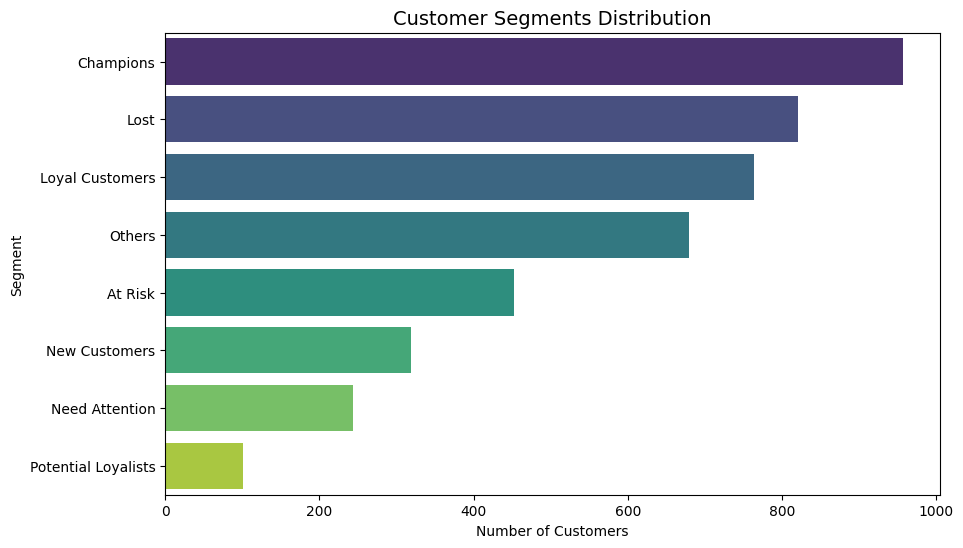

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Customer Segments Distribution', fontsize=14)
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.show()

In [12]:
# Export full RFM + Segment data
rfm.to_excel('../excel/customer_segments_rfm.xlsx', index=False)

# Export summary
segment_summary.to_excel('../excel/segment_summary.xlsx')

print("Excel files saved successfully!")

Excel files saved successfully!


In [ ]:
# Key Insights & Recommendations

## Key Insights

1. **Champions (957 customers)** are your best customers — they buy recently, frequently, and spend the most.
2. **Loyal Customers (764)** are also very valuable and should be nurtured.
3. A large number of customers are **Lost (821)** or **At Risk (453)** — these need re-engagement campaigns.
4. **New Customers (319)** show potential and should be converted into loyal customers.
5. There is a clear opportunity to move customers from “Potential Loyalists” and “Need Attention” into higher-value segments.

## Business Recommendations

1. **Champions & Loyal Customers**  
   - Offer loyalty rewards, early access to new products, and exclusive deals.

2. **At Risk & Need Attention**  
   - Launch win-back campaigns (discounts, personalized emails).

3. **Lost Customers**  
   - Run re-activation campaigns or surveys to understand why they left.

4. **New Customers**  
   - Focus on onboarding and second-purchase incentives.

5. **General**  
   - Use these segments for targeted marketing instead of treating all customers the same.